<a href="https://colab.research.google.com/github/sebenemaryamashebir-cmd/cassava-disease-detector/blob/tracy/cassava_leaf_disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



>



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
zip_path = "/content/drive/MyDrive/Cassava_Project/data.zip"

extract_path = "/content/cassava_dataset"

In [4]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os

os.listdir(extract_path)

['Cassava___healthy',
 'Cassava___brown_streak_disease',
 'Cassava___bacterial_blight',
 'Cassava___mosaic_disease',
 'Cassava___green_mottle']

In [6]:
import os

dataset_path = "/content/cassava_dataset"

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} images")


Cassava___healthy: 2577 images
Cassava___brown_streak_disease: 2189 images
Cassava___bacterial_blight: 1087 images
Cassava___mosaic_disease: 13158 images
Cassava___green_mottle: 2386 images


#**Data preparation**

## EDA
here it could be seen that my data is imbalanced. Cassava mosaic disease accounts for about 61% of all images whearas there is cassava bacteria blight disease that account for only about 5% of the images. this could cause accuracy problems during training and testing.Thus accurate processing strategy is needed for data. Thus we introduced augmentation methods like increasing variability for minority.



###Data Visualisation

In [7]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

####leave inspection
taking radom leaves from each set of leaves to analtse.
aside from the healthy leave which could be easily distinguished , the bacteriablight sometimes look like brown streak and the green mottle sometimes look like the mosaic disease.this may cause some confusion during model classification(a hypothesis) we will find out if this hypothesis is true using the confusion matrix.

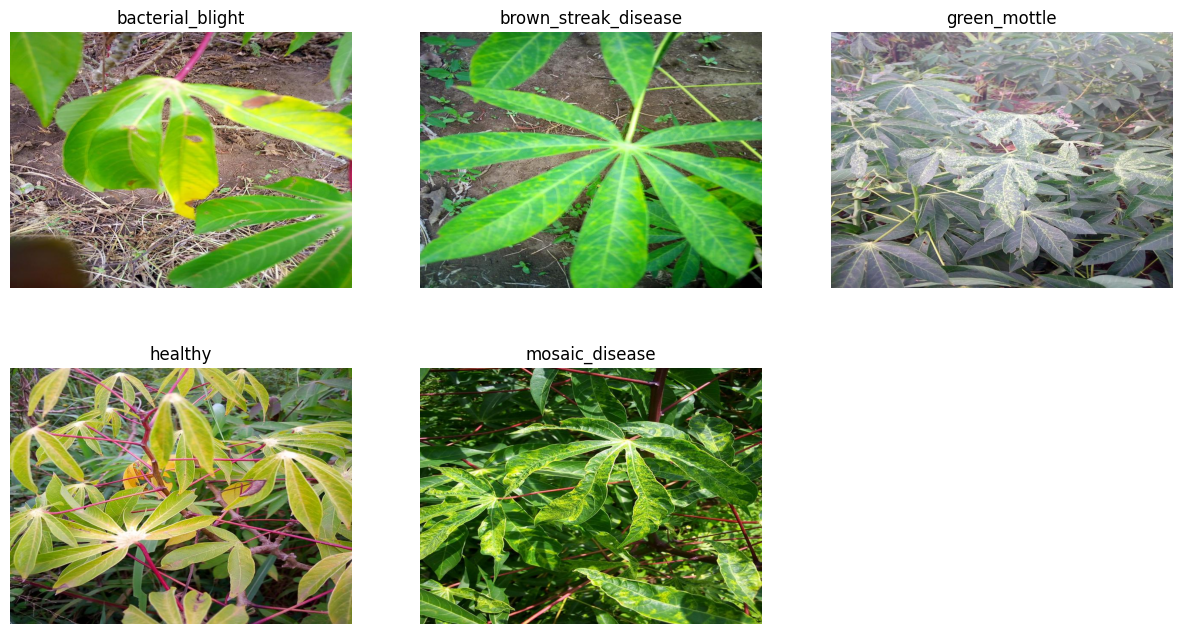

In [8]:
dataset_path = "/content/cassava_dataset"

classes = sorted(os.listdir(dataset_path))

plt.figure(figsize=(15,8))

for i, class_name in enumerate(classes):

    class_folder = os.path.join(dataset_path, class_name)

    image_name = random.choice(os.listdir(class_folder))

    image_path = os.path.join(class_folder, image_name)

    img = Image.open(image_path)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(class_name.replace("Cassava___",""))
    plt.axis("off")

plt.show()

####image sizes
could be seen that images are of same size (800,600), so there would be no need for resizing into a single size.

In [9]:
from PIL import Image
import os

dataset_path = "/content/cassava_dataset"

sizes = []

for class_name in os.listdir(dataset_path):

    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):

        for image_name in os.listdir(class_folder):

            image_path = os.path.join(class_folder,image_name)

            img = Image.open(image_path)

            sizes.append(img.size)

In [10]:
unique_sizes = set(sizes)

print("Number of unique image sizes:", len(unique_sizes))

print(unique_sizes)

Number of unique image sizes: 1
{(800, 600)}


####corrupted images
here we checked if there are any corrupted images, like images that cannot be opened, since a corrupted image could cause an abrupt stop during training.we used img.verify instead of img.open because image.open only opens the file heade and doesnot give internal details but with img.verify it checks whether image file is complete and readable.

In [11]:
from PIL import Image
import os

dataset_path = "/content/cassava_dataset"

corrupted_images = []

for class_name in os.listdir(dataset_path):

    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):

        for image_name in os.listdir(class_folder):

            image_path = os.path.join(class_folder, image_name)

            try:
                img = Image.open(image_path)
                img.verify()   # Verify image integrity

            except Exception:
                corrupted_images.append(image_path)

print("Number of corrupted images:", len(corrupted_images))

Number of corrupted images: 0


####class distribution
from the bar plot it could be seen that images for mozaic disease is dominant with bacteria blight disease having the least number of images.This might cause the model to be more accurate with classifying MD than the rest of the diseases.
we will fix this problem sing data augmentation, that is during training we will rotate, flipp, slightly zoom and make images from the minority classes slightly brighter. we will also use class weights, that is when definning our loss function, classes with fewer images will receive higher weights so that making a mistake with classes with fewer images would costly.

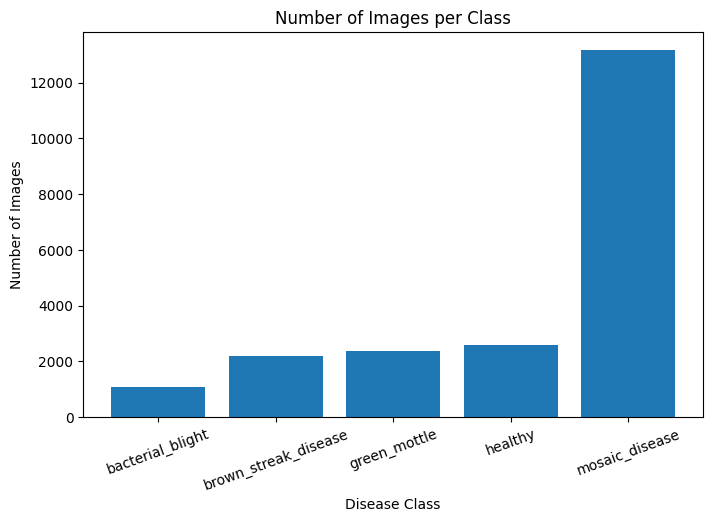

In [12]:
import matplotlib.pyplot as plt
import os

dataset_path = "/content/cassava_dataset"

classes = []
counts = []

for class_name in sorted(os.listdir(dataset_path)):

    class_folder = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_folder):

        classes.append(class_name.replace("Cassava___", ""))
        counts.append(len(os.listdir(class_folder)))

plt.figure(figsize=(8,5))
plt.bar(classes, counts)

plt.title("Number of Images per Class")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)

plt.show()

###Data processing

####Splitting dataset
train set of 80%
validation set of 10%
test set of 10%

In [13]:
import torch
from torchvision import datasets
from torch.utils.data import random_split

#Load dataset
dataset_path = "/content/cassava_dataset"

dataset = datasets.ImageFolder(root=dataset_path)

print("Total images:", len(dataset))

#split dataset

train_size = int(0.80 * len(dataset))
val_size = int(0.10 * len(dataset))
test_size = len(dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)


train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
     generator=generator
)

#verify spit
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))



Total images: 21397
Training images: 17117
Validation images: 2139
Testing images: 2141


####Resize images
we neeed every image in the batch to have sme size dimension which our dataset already hava. however dealing with a 800x600 size images require much more memory, makes training, and require more computations in every convulation layer. so we will use 224x224.

####Normalisation
here we scale the pixel values of an image to  smaller consistent range.since neural networks generally becomes better when inputs are on similar scale(instead of rgb with diferent values) we therefore need nrmalisation for standardisation where pixel values lie between 0 and 1. the ToTensor() does that normalisation.

In [14]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

####Augmentation
Here our goal is to make the model see thesame disease in many different ways.
here we deal with different variance of the leaves, however since its cassava leave not every transformation makes sense. so we will consider Horizontal flip, small rotation(10-20 degrees), slight zoom,random crop,brightness/contrast.

In [15]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor()
])

###ImageFolder
We want pytorch to have an understanding of our data folder. we understand that each folder folder represents a disease but pytorch doesnot. so we use imageFolder to let pytorch reads dataset folders, automatically assign labels, apply preprocessing transforms and return an image and its label whenever requested.
after this step, pytorch will now know where my images are, give labels(0,1,2,3,4) to every set of image diseas,automatically resise every image and lastly convert images into yensor of shape 3x224x224 which means 3 chanels(RGB) height of 224 and width of 224.

In [16]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root="/content/cassava_dataset",
    transform=train_transform
)
print(len(train_dataset))
print(train_dataset.classes)
print(train_dataset.class_to_idx)#what labels did pytorch give

21397
['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']
{'Cassava___bacterial_blight': 0, 'Cassava___brown_streak_disease': 1, 'Cassava___green_mottle': 2, 'Cassava___healthy': 3, 'Cassava___mosaic_disease': 4}


In [17]:
image, label = train_dataset[0]

print(type(image))
print(image.shape)
print(label)

<class 'torch.Tensor'>
torch.Size([3, 224, 224])
0


###DataLoader
here we specify how we load the data into the model, do we give it one image at a time, all images or images in batch. this is to make sure that the model is learning efficiently without giving it too much or too less load. in this project we chose mini batch gradient descent of size 32. what this does is it takes 32 images at a time(shuffled) passes them to the cnn model, then gives 32 predictions.

In [18]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

#inspecting one mini batch
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])
